In [66]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib as mpl
import scipy
import pandas as pd
import pickle

import onep

In [2]:
#Multiple mice
import pickle

# Load the pickle file
with open('/Users/suthardr/Desktop/collection_cxtb_fc.pkl', 'rb') as file:
    collection_cxtb_fc = pickle.load(file)

timestamps = collection_cxtb_fc.animals['astro7'].Timestamps.to_numpy()[:3303].squeeze()
timestamps

array([0.00000000e+00, 9.99234464e-02, 1.99846893e-01, ...,
       3.29747373e+02, 3.29847297e+02, 3.29947220e+02])

In [158]:
umap_df = pd.read_pickle("/Users/suthardr/Desktop/WaveMap_Plots/Recall_CXTB/umap_recall_cxtB_15.pkl")


In [151]:
umap_df

In [159]:
#Sort your umap_df by cluster_id for plotting
umap_df = umap_df.sort_values(['cluster_id'])

#Make into a cute little numpy array and save as result
numpy_list = [array for array in umap_df['waveform']]
result = np.vstack(numpy_list)

In [97]:
result

array([['[-4.21268380e-01 -2.59859159e-01 -3.57077434e-03  1.02685846e-01\n -8.19099722e-02  3.54263718e-01 -4.71803056e-01 -6.72677478e-02\n  1.02410054e-01 -3.96742760e-02  1.16572512e-01 -2.10385852e-01\n -2.47086023e-02 -5.17874133e-01 -2.12267607e-01 -8.79231491e-02\n  2.20754770e-01  1.55482151e-01 -1.28149037e-01 -3.96720877e-01\n -1.22678816e-01 -4.09632092e-02 -2.07079836e-02  1.00044403e-01\n -2.35171862e-01 -6.00559967e-01 -8.76882732e-02 -1.37924146e-01\n -3.62659091e-02 -1.39004625e-01 -4.30767537e-01 -3.25988253e-01\n -1.94311549e-01 -5.96360359e-01 -3.79577085e-01 -1.42348803e-01\n  1.58044441e-01  1.64902344e-01 -4.60165245e-01 -4.96242985e-01\n -5.12323950e-01 -5.09300941e-01 -5.53047515e-01 -7.50495287e-01\n -8.58286382e-01 -6.70668806e-01 -7.26382853e-01 -4.34879720e-01\n -4.01814453e-01 -2.96115600e-01 -9.69899737e-01 -8.66010395e-01\n -3.16462610e-01 -9.02674457e-01 -8.13190084e-01 -2.49024243e-01\n -4.39826212e-01 -4.69213559e-01 -4.43345290e-01 -5.28648005e-01\n 

Text(52.722222222222214, 0.5, 'Cell #')

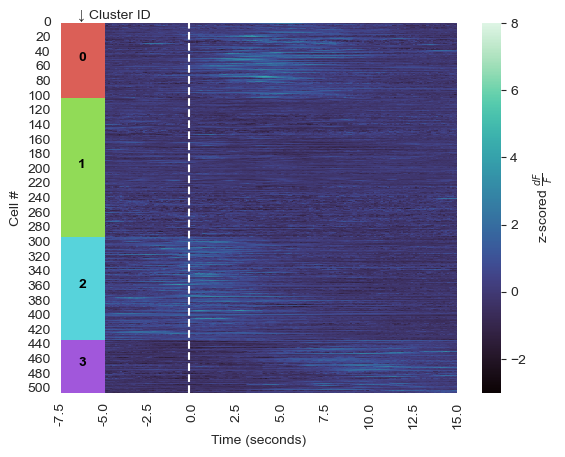

In [160]:
fig, ax = plt.subplots()

Ks=4 #What number of clusters are you plotting?
labels=umap_df['cluster_id']
cmap = sns.color_palette('hls', 4) #Change here the number of colors needed (# clusters)

# -> Cosmetic code to create a Rectangle patches to label specific K-cluster
Koffset = 0

sns.heatmap(result, cbar=True, cbar_kws={"label": r"z-scored $\frac{dF}{F}$"},cmap='mako',ax=ax, vmin=-3, vmax=8)
for Ki in range(Ks):
    Nk = np.size(np.where(labels == Ki))
    # 40 is width of the rectangle
    rect = mpl.patches.Rectangle((0, Koffset), 25, Nk, linewidth=1, edgecolor='none', facecolor=cmap[Ki])
    ax.text(10, Koffset + Nk/2, Ki ,color='k', weight='bold')
    # Add the patch to the plot
    ax.add_patch(rect)
    Koffset += Nk
ax.text(10,-5,'↓ Cluster ID',fontsize=10)
# <- end of cosmetic code

ax.set_xticks(np.linspace(0, result.shape[1], 10),
labels=np.linspace(-7.5, 15, 10))
ax.axvline(x=73, color='white', linestyle='--')

ax.set_xlabel('Time (seconds)')
ax.set_ylabel('Cell #')

In [161]:
fig.savefig("/Users/suthardr/Desktop/recall_CXTB_zscored_detected_heatmap15sec.png")

In [162]:
cluster0 = umap_df[umap_df['cluster_id']== 0]
numpy_list = [array for array in cluster0['waveform']]
cluster0 = np.vstack(numpy_list)

cluster1 = umap_df[umap_df['cluster_id']== 1]
numpy_list = [array for array in cluster1['waveform']]
cluster1 = np.vstack(numpy_list)

cluster2 = umap_df[umap_df['cluster_id']== 2]
numpy_list = [array for array in cluster2['waveform']]
cluster2 = np.vstack(numpy_list)

cluster3 = umap_df[umap_df['cluster_id']== 3]
numpy_list = [array for array in cluster3['waveform']]
cluster3 = np.vstack(numpy_list)

# cluster4 = umap_df[umap_df['cluster_id']== 4]
# numpy_list = [array for array in cluster4['waveform']]
# cluster4 = np.vstack(numpy_list)

# cluster5 = umap_df[umap_df['cluster_id']== 5]
# numpy_list = [array for array in cluster5['waveform']]
# cluster5 = np.vstack(numpy_list)
#
# cluster6 = umap_df[umap_df['cluster_id']== 6]
# numpy_list = [array for array in cluster6['waveform']]
# cluster6 = np.vstack(numpy_list)
#
# cluster7 = umap_df[umap_df['cluster_id']== 7]
# numpy_list = [array for array in cluster7['waveform']]
# cluster7 = np.vstack(numpy_list)

Text(52.722222222222214, 0.5, 'Cell #')

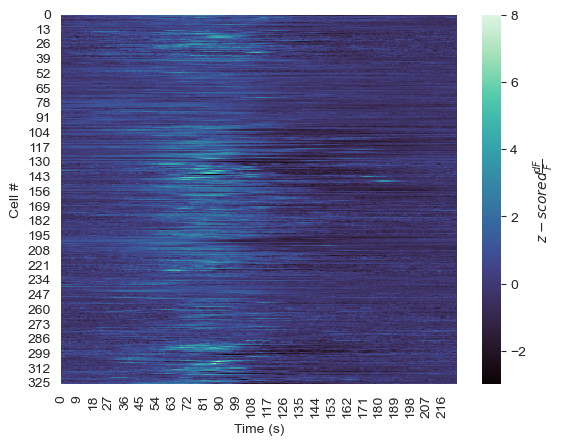

In [144]:
# Want to plot a heatmap for a specific cluster?

# Major ticks every 20, minor ticks every 5
fig, ax = plt.subplots()

sns.heatmap(cluster3, cbar=True, cbar_kws={"label": r"$z-scored \frac{dF}{F}$"}, cmap='mako', ax=ax, vmin=-3, vmax=8)
ax.set_xlabel('Time (s)')
ax.set_ylabel('Cell #')
# ax.set_xticks(np.linspace(0, cluster0.shape[1], 12),
# labels=np.linspace(0, 330, 12, dtype=np.int))
# ax.set_yticks(np.linspace(0, cluster0.shape[0], 10),
# labels=np.linspace(0, 32, 10, dtype=np.int))

#Save that heatmap as a png because svg will blow up your laptop
#fig.savefig('/Users/suthardr/Desktop/recall_cxtb_heatmap_clusterzoom.png')


In [ ]:
# Define a list of astro instances
# astro_instances = [astro_3, astro_4, astro_5, astro_6]
#
# # Loop over each astro instance
# for idx, astro in enumerate(astro_instances, start=3):
#     # Slice the accepted traces and transpose
#     sliced_df = astro.accepted_traces.to_numpy()[:3303].T
#
#     # Perform z-score normalization along the second axis
#     # sliced_dfz = stats.zscore(sliced_df, axis=1)
#
#     # Save sliced_dfz to a numpy file
#     np.save(f'/Users/suthardr/Desktop/sliced_dfz{idx}.npy', sliced_dfz)

In [ ]:
max_indices = np.argmax(across_eta_, axis=1)
time = np.linspace(-5, 15, 5)
# time = np.linspace(-15, 30, 5)
sorted_ind = np.argsort(max_indices)
sorted_arr = across_eta_[sorted_ind]
fig, ax = plt.subplots()
ax.axvline(x=55, color='white', linestyle='--')
sns.heatmap(sorted_arr, cmap='mako',cbar=True, cbar_kws={"label": r"$\frac{dF}{F}$"})
ax.set_xticks(np.linspace(0, len(across_eta_.T), 5), time)
ax.set_title('Astro4 Avg Sequence')
# ax.set_title('Recall Cells: Active FC-Recall Sorted from FC')
ax.set_xlabel('Time (seconds)')
ax.set_ylabel('Cell #')
#plt.savefig('/Users/suthardr/Desktop/Astro4_recall_sequenceAVG_zheatmap.png')

In [ ]:
ax= onep.plot_whole_eta(across_eta_, ci='tci')
time = np.linspace(-5, 15, 5)
# time = np.linspace(-15, 30, 6)
ax.set_xticks(np.linspace(0, len(across_eta_.T), 5), time)
ax.set_title('Astro4 Freeze Onset: CFC')
ax.set_xlabel('Time (seconds)')
ax.set_ylabel('dF/F')
ax.axvline(x=55, color='black', linestyle='--')
plt.savefig('/Users/suthardr/Desktop/Astro4_fc_freeze_onset_15sec.svg')

In [ ]:

max_indices = np.argmax(across_eta_, axis=1)
time = np.linspace(-5, 15, 5)
# time = np.linspace(-15, 30, 5)
sorted_ind = np.argsort(max_indices)
sorted_arr = across_eta_[sorted_ind]
fig, ax = plt.subplots()
ax.axvline(x=55, color='white', linestyle='--')
sns.heatmap(sorted_arr, cmap='mako',cbar=True, cbar_kws={"label": r"$\frac{dF}{F}$"})
ax.set_xticks(np.linspace(0, len(across_eta_.T), 5), time)
ax.set_title('Astro3 Recall Freeze Onset')
# ax.set_title('Recall Cells: Active FC-Recall Sorted from FC')
ax.set_xlabel('Time (seconds)')
ax.set_ylabel('Cell #')
plt.savefig('/Users/suthardr/Desktop/Astro3_recall_freeze_onset_heatmap.png')

<Axes: >

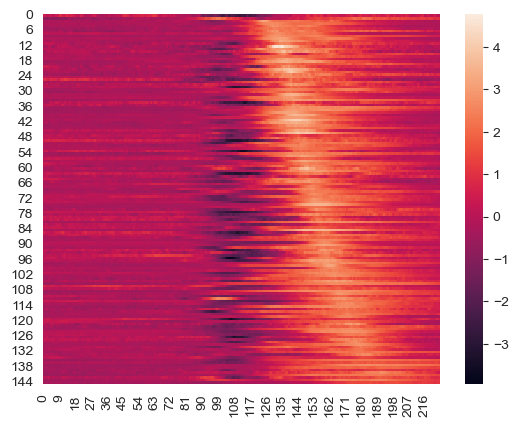

In [51]:
max_indices = np.argmax(cluster1, axis=1)
sorted_ind = np.argsort(max_indices)
sorted_arr = cluster1[sorted_ind]
sns.heatmap(sorted_arr)